# Pallas grids and BlockSpecs

CPU companion; no accelerator is required. TPU execution not validated.

- Implement an actual Pallas Ref-writing kernel with grid and BlockSpecs.
- Derive block coordinates and distinguish them from element offsets.
- Handle nondivisible matrix tails explicitly and verify full output coverage.
- Separate CPU interpretation from accelerator execution evidence.

A kernel can produce the right answer on a divisible matrix and silently miss the last row on a real workload. How do grid coordinates, block ownership and array boundaries fit together? We will implement an actual Pallas operation and make its tail handling visible.

## The idea

A Pallas grid assigns work to programs, and BlockSpec maps those programs to array regions. Boundary tiles make the distinction between logical data and padded storage important. Verify ownership before optimizing arithmetic.

## Map every logical element to an owning program

The lesson's five-by-eleven matrix is covered by nine program IDs. Those IDs are categories, not measured magnitudes. Tile outlines and a discrete legend show which program owns each region without implying that a higher ID performs more work.

At an edge, the physical tile extends beyond the logical matrix. This implementation pads the inputs before the kernel, making each block access valid, then crops the result back to the logical shape. A padded slot is storage for the computation, not an extra observation or logical output.

Enumerate coordinates independently and verify coverage of every valid element. Then test dimensions that are not multiples of the tile size; perfectly divisible fixtures can conceal boundary mistakes.

### Program coordinates and partial boundary tiles

**Predict:** Why test an awkward shape in addition to a tile-aligned shape?

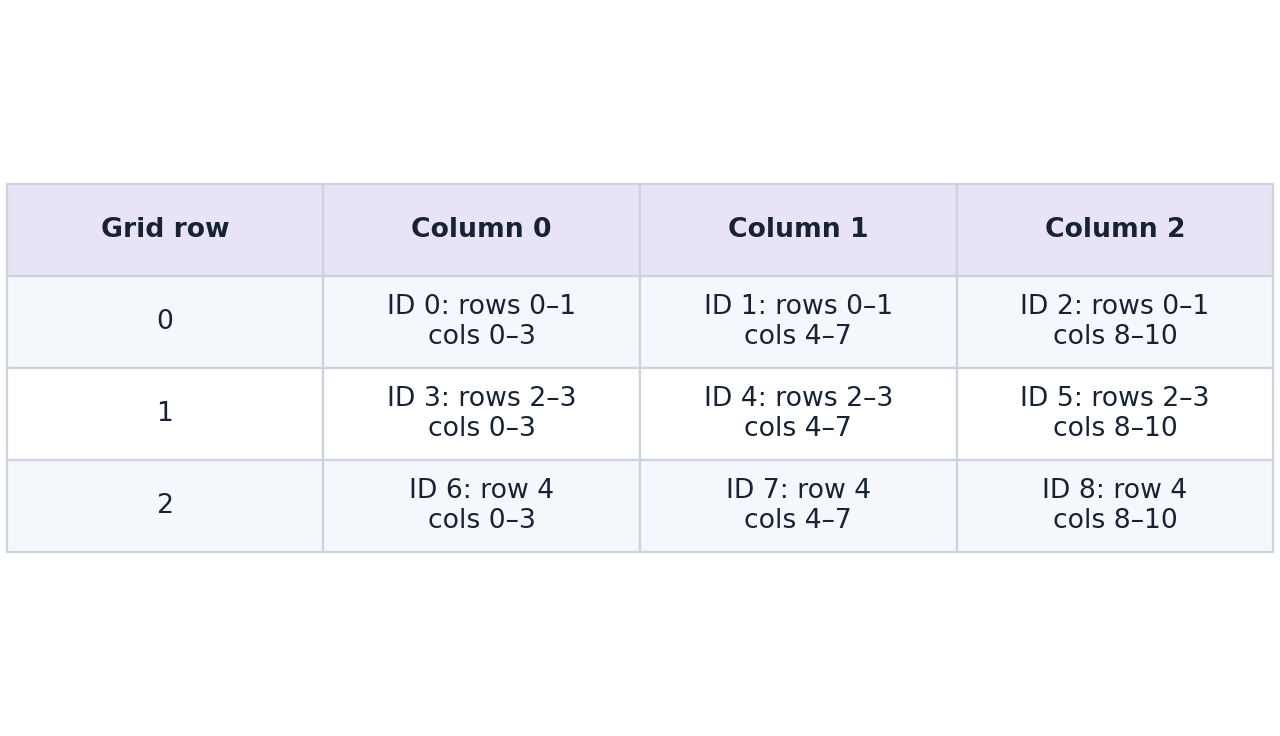

*Conceptual / analytic teaching diagram; not a recorded benchmark.*

Two-by-four tiles cover a five-by-eleven logical matrix. Each cell lists a program ID and valid row/column range. Bottom and right tiles are partial; accesses outside the logical range need boundary treatment. Program IDs are categories, matching the corrected discrete ownership heatmap. Here explicit padding makes whole-block accesses valid; cropping removes artificial output positions.

### Pause and reason

Why test an awkward shape in addition to a tile-aligned shape?

<details><summary>Compare your reasoning</summary>

It exercises partial boundary tiles and guards. A tile-aligned case never asks the implementation to distinguish padded positions from valid data.

</details>

## Write the simplest useful contract

Two nonempty matrices have the same shape and dtype; the result has that shape and dtype. The kernel computes in float32 and casts once at its output, supporting float32 and bfloat16 inputs. This explicit precision policy becomes important later. A function returning an array is not the kernel body contract: the body reads input Refs and writes every element of its output Ref.

## A grid coordinate is not an element coordinate

For a $(5,11)$ matrix and $(2,4)$ blocks, the grid is $(3,3)$. Invocation $(i,j)$ owns rows starting at $2i$ and columns starting at $4j$. The BlockSpec index map returns block coordinates $(i,j)$; Pallas applies the block-size scaling. Confusing this with element offsets can produce skipped regions or out-of-bounds windows.

$$
G_m=\left\lceil\frac{M}{B_m}\right\rceil,\quad G_n=\left\lceil\frac{N}{B_n}\right\rceil
$$

## Make boundary behavior explicit

We pad both inputs to $(6,12)$, launch complete blocks and crop the output to $(5,11)$. This avoids relying on implicit out-of-bounds reads or uninitialized output cells. There are $55$ logical elements and $72$ padded elements, so $17$ elements represent extra work. Padding with zeros is harmless here because each output depends only on corresponding input elements. A reduction, softmax or stencil would require a separate padding argument.

## Check ownership and arithmetic separately

The ownership map comes from integer row/column arithmetic, independent of the kernel result. The value reference comes from NumPy. Checking only a mean could hide a missing or swapped tile; compare every element and explicitly inspect the last row and column. A different block size must change work partitioning while preserving the logical result.

## Interpretation proves bounded semantics, not speed

The call sets interpret=True, which runs actual Pallas semantics through a CPU-compatible execution path. This verifies the grid, Ref operations and numerical results for the fixture. It does not validate TPU layout constraints, target lowering, memory overlap or accelerator throughput. The next lesson introduces a separate TPU-only path that refuses to substitute interpretation when target hardware is absent.

## Write a block-local kernel and a boundary-aware wrapper

Create main.py for the first block, then append each block in order in your course CPU environment.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
from jax.experimental import pallas as pl
from jax.experimental.pallas import tpu as pltpu

def validate_pair(x,y,block):
    if x.ndim!=2 or x.shape!=y.shape or min(x.shape)<1:
        raise ValueError("inputs must be nonempty matrices with identical shapes")
    if x.dtype!=y.dtype or x.dtype not in (jnp.float32,jnp.bfloat16):
        raise ValueError("matching float32 or bfloat16 inputs required")
    if len(block)!=2 or any(not isinstance(n,int) or n<1 for n in block):
        raise ValueError("two positive integer block dimensions required")

def pad_pair(x,y,block):
    validate_pair(x,y,block)
    m,n=x.shape;bm,bn=block
    padded=((m+bm-1)//bm*bm,(n+bn-1)//bn*bn)
    pads=((0,padded[0]-m),(0,padded[1]-n))
    return jnp.pad(x,pads),jnp.pad(y,pads),padded

def axpy_body(x_ref,y_ref,out_ref):
    result=2.0*x_ref[...].astype(jnp.float32)+y_ref[...].astype(jnp.float32)
    out_ref[...]=result.astype(out_ref.dtype)

def blocked_axpy(x,y,block=(2,4)):
    px,py,padded=pad_pair(x,y,block)
    bm,bn=block
    spec=pl.BlockSpec(block,lambda i,j:(i,j))
    out=pl.pallas_call(axpy_body,
        out_shape=jax.ShapeDtypeStruct(padded,x.dtype),
        grid=(padded[0]//bm,padded[1]//bn),
        in_specs=(spec,spec),out_specs=spec,interpret=True)(px,py)
    return out[:x.shape[0],:x.shape[1]]

The kernel writes its output Ref and returns nothing. The wrapper validates and pads the global matrices, defines ownership with BlockSpecs, launches actual Pallas interpretation and crops to the original shape.

## Check every logical element against NumPy

Create main.py for the first block, then append each block in order in your course CPU environment.

In [2]:
x=jnp.arange(55,dtype=jnp.float32).reshape(5,11)/10-2
y=jnp.full_like(x,0.25)
actual=blocked_axpy(x,y)
reference=2*np.asarray(x)+np.asarray(y)
assert actual.shape==(5,11)
np.testing.assert_allclose(actual,reference,rtol=1e-6,atol=1e-6)
assert float(actual[-1,-1])==float(reference[-1,-1])
print("Shape and boundary:",actual.shape,float(actual[0,0]),float(actual[-1,-1]))

Shape and boundary: (5, 11) -3.75 7.050000190734863


The last row and column belong to partial logical tiles. Checking them explicitly catches floor-divided grids that omit the tail.

## Derive the ownership map independently

Create main.py for the first block, then append each block in order in your course CPU environment.

In [3]:
rows,cols=np.indices((5,11))
owner=(rows//2)*3+(cols//4)
assert owner[0,0]==0 and owner[4,10]==8
logical=5*11;padded=6*12
print("Grid:",(3,3),"logical/padded elements:",logical,padded)
print("Padding fraction:",(padded-logical)/padded)

Grid: (3, 3) logical/padded elements: 55 72
Padding fraction: 0.2361111111111111


Block coordinates are multiplied by the block shape by Pallas. An index map returning (i,j) selects the corresponding block; multiplying those indices again would skip data.

## Run the example

In [4]:
import jax
import jax.numpy as jnp
import numpy as np
from jax.experimental import pallas as pl
from jax.experimental.pallas import tpu as pltpu

def validate_pair(x,y,block):
    if x.ndim!=2 or x.shape!=y.shape or min(x.shape)<1:
        raise ValueError("inputs must be nonempty matrices with identical shapes")
    if x.dtype!=y.dtype or x.dtype not in (jnp.float32,jnp.bfloat16):
        raise ValueError("matching float32 or bfloat16 inputs required")
    if len(block)!=2 or any(not isinstance(n,int) or n<1 for n in block):
        raise ValueError("two positive integer block dimensions required")

def pad_pair(x,y,block):
    validate_pair(x,y,block)
    m,n=x.shape;bm,bn=block
    padded=((m+bm-1)//bm*bm,(n+bn-1)//bn*bn)
    pads=((0,padded[0]-m),(0,padded[1]-n))
    return jnp.pad(x,pads),jnp.pad(y,pads),padded

def axpy_body(x_ref,y_ref,out_ref):
    result=2.0*x_ref[...].astype(jnp.float32)+y_ref[...].astype(jnp.float32)
    out_ref[...]=result.astype(out_ref.dtype)

def blocked_axpy(x,y,block=(2,4)):
    px,py,padded=pad_pair(x,y,block)
    bm,bn=block
    spec=pl.BlockSpec(block,lambda i,j:(i,j))
    out=pl.pallas_call(axpy_body,
        out_shape=jax.ShapeDtypeStruct(padded,x.dtype),
        grid=(padded[0]//bm,padded[1]//bn),
        in_specs=(spec,spec),out_specs=spec,interpret=True)(px,py)
    return out[:x.shape[0],:x.shape[1]]

x=jnp.arange(55,dtype=jnp.float32).reshape(5,11)/10-2
y=jnp.full_like(x,0.25)
actual=blocked_axpy(x,y)
reference=2*np.asarray(x)+np.asarray(y)
assert actual.shape==(5,11)
np.testing.assert_allclose(actual,reference,rtol=1e-6,atol=1e-6)
assert float(actual[-1,-1])==float(reference[-1,-1])
print("Shape and boundary:",actual.shape,float(actual[0,0]),float(actual[-1,-1]))

rows,cols=np.indices((5,11))
owner=(rows//2)*3+(cols//4)
assert owner[0,0]==0 and owner[4,10]==8
logical=5*11;padded=6*12
print("Grid:",(3,3),"logical/padded elements:",logical,padded)
print("Padding fraction:",(padded-logical)/padded)

Shape and boundary: (5, 11) -3.75 7.050000190734863
Grid: (3, 3) logical/padded elements: 55 72
Padding fraction: 0.2361111111111111


Expected: Logical shape (5,11); endpoints -3.75 and approximately 7.05. Grid (3,3); 55 logical versus 72 padded elements.

## Nine programs cover a matrix with partial boundary tiles

Predict: Which program owns the last logical element, and why does the grid need a third row and column?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
visual_data={'kind':'heatmap','values':owner.tolist(),'unit':'program ID (categorical label)','rows':[str(i) for i in range(5)],'columns':[str(i) for i in range(11)],'xlabel':'logical column','ylabel':'logical row'}

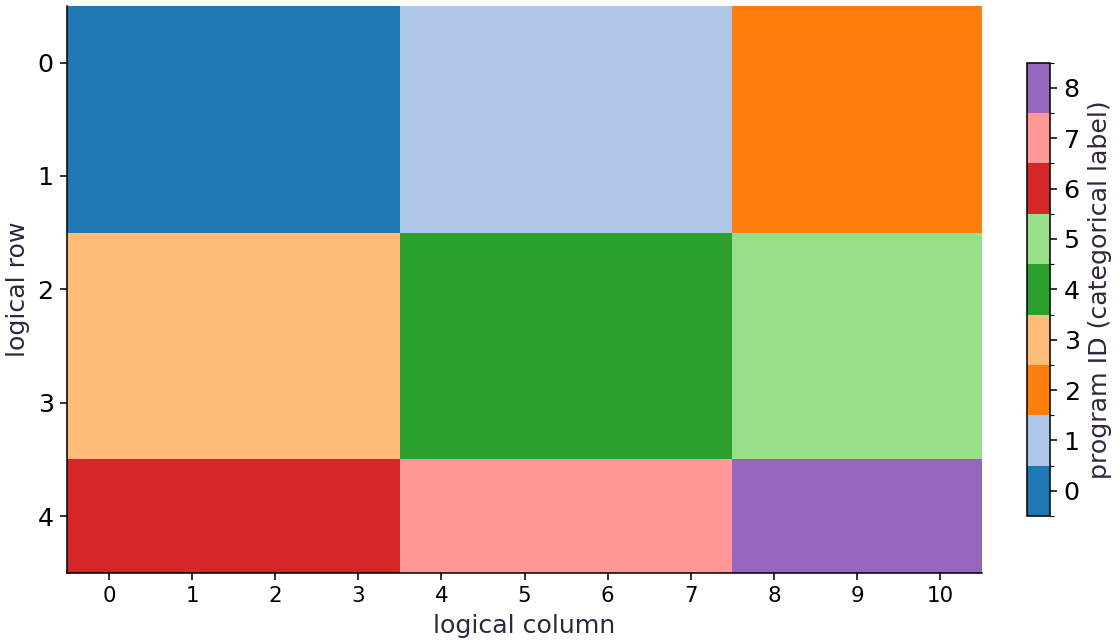

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

Rows and columns are logical matrix coordinates. Each color identifies the program that owns that cell, using the program-ID labels on the colorbar under $(2,4)$ blocks. Program IDs are labels, not execution time or device IDs. Programs zero through two cover the first two rows; programs six through eight cover the last logical row.

The bottom-right cell belongs to program $8$. Its logical region has only one row and three columns, although the launched block has two rows and four columns. The padded cells are intentionally outside this cropped ownership display.

### Connect it to the computation

The independent ownership arithmetic agrees with a $(3,3)$ grid over a padded $(6,12)$ buffer. The numerical Pallas result is separately compared element by element with NumPy, including the bottom-right value of about $7.05$.

Color differences do not imply parallel execution or different speeds. This CPU interpretation figure explains mapping and boundaries; TPU scheduling and layout constraints need their own target-specific evidence.

## Change block geometry without changing values

Predict: Will blocks of $(3,5)$ change the logical answer?

In [7]:
changed=blocked_axpy(x,y,(3,5))
np.testing.assert_allclose(changed,reference,rtol=1e-6,atol=1e-6)
print("Changed grid:",(2,3),"same numerical result")

Changed grid: (2, 3) same numerical result


Expected: The grid becomes (2,3); the logical output is unchanged.

Grid geometry is an implementation choice for this independent elementwise operation. It must not alter the mathematical contract.

## Expose the floor-division omission

Predict: How many logical cells would a grid built with floor division cover?

In [8]:
covered=np.zeros((5,11),dtype=bool)
for i in range(5//2):
    for j in range(11//4):
        covered[i*2:(i+1)*2,j*4:(j+1)*4]=True
assert int(covered.sum())==32
assert not covered[-1,-1]
print("Floor-grid missing logical cells:",int((~covered).sum()))

Floor-grid missing logical cells: 23


Expected: A floor-divided grid misses 23 of the 55 logical cells.

This diagnostic models the ownership bug without reading uninitialized kernel memory. Ceiling division plus an explicit tail policy repairs it.

## Your exercise

Test a singleton row and a changed nondivisible matrix with negative values. Verify full NumPy agreement and exact output shapes for two block choices.

In [9]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [10]:
for shape in [(1,7),(7,9)]:
    a=jnp.asarray(np.random.default_rng(11).normal(size=shape),dtype=jnp.float32)
    b=jnp.asarray(np.random.default_rng(12).normal(size=shape),dtype=jnp.float32)
    for block in [(2,4),(3,5)]:
        result=blocked_axpy(a,b,block)
        assert result.shape==shape
        np.testing.assert_allclose(result,2*np.asarray(a)+np.asarray(b),rtol=1e-6,atol=1e-6)
print("Singleton and changed tails verified")

Singleton and changed tails verified


## Reject a broadcast that changes the contract · Practice

Pass a column-shaped second input and confirm the wrapper rejects it before launching the kernel. Explain why silent broadcasting would hide an input-contract error.

Hint: Require identical matrix shapes, not merely broadcast-compatible shapes.

In [11]:
# Write your attempt here.

## Reference reasoning

The operation promises paired matrices. A separate row/column-bias kernel can define an intentional broadcast contract.

In [12]:
rejected=False
try:blocked_axpy(x,jnp.ones((5,1),dtype=jnp.float32))
except ValueError:rejected=True
assert rejected
print("Mismatched global shape rejected")

Mismatched global shape rejected


## Measure padding overhead without claiming runtime · Challenge

For shapes (5,11) and (33,129), compare logical elements, padded elements and program counts for three block choices. Explain why fewer programs may still mean more work.

Hint: Use integer ceiling division; do not time interpretation as accelerator performance.

In [13]:
# Write your attempt here.

## Reference reasoning

Program count and padded work expose different costs. Actual target measurements are still needed to rank configurations.

In [14]:
for shape in [(5,11),(33,129)]:
    counts=[]
    for bm,bn in [(2,4),(8,128),(16,256)]:
        gm=(shape[0]+bm-1)//bm;gn=(shape[1]+bn-1)//bn
        counts.append((bm,bn,gm*gn,gm*gn*bm*bn))
    assert all(padded>=shape[0]*shape[1] for _,_,_,padded in counts)
    print("Shape, block/program/padded counts:",shape,counts)

Shape, block/program/padded counts: (5, 11) [(2, 4, 9, 72), (8, 128, 1, 1024), (16, 256, 1, 4096)]
Shape, block/program/padded counts: (33, 129) [(2, 4, 561, 4488), (8, 128, 10, 10240), (16, 256, 3, 12288)]


## Checkpoint

For block shape (2,4), what does a BlockSpec index map returning (i,j) select?

1. A block whose element origin is (2i,4j).
2. One scalar element at (i,j).
3. A block whose origin must be multiplied by block sizes again inside the index map.

## Diagnose

If only the boundary is wrong, inspect ceiling division, padding and cropping before editing arithmetic. If blocks skip input regions, check whether the index map returns block coordinates or incorrectly pre-multiplied offsets. If a mean looks right but full comparison fails, inspect tile permutation or duplicate ownership.

## Evidence

Independent full-array comparisons, ownership map, tail fixtures and a floor-grid omission diagnosis. Keep the environment, observed outputs and your explanation of the figure.

## Carry forward

- Write the simplest useful contract
- A grid coordinate is not an element coordinate
- Make boundary behavior explicit
- Check ownership and arithmetic separately
- Interpretation proves bounded semantics, not speed

## Primary references

- [Pallas grids and block specifications](https://docs.jax.dev/en/latest/pallas/grid_blockspec.html)
- [Writing TPU kernels: layout and memory restrictions](https://docs.jax.dev/en/latest/pallas/tpu/details.html)
- [TPU pipelining and emit_pipeline](https://docs.jax.dev/en/latest/pallas/tpu/pipelining.html)
- [TPU interpretation is simulation, not target execution](https://docs.jax.dev/en/latest/_autosummary/jax.experimental.pallas.tpu.InterpretParams.html)